# **incêndios florestais no Brasil** <p>
Os incêndios florestais são um grave problema para a preservação das Florestas Tropicais. Compreender a frequência de incêndios florestais em uma série temporal pode ajudar a tomar medidas para evitá-los.
O Brasil tem a maior floresta tropical do planeta que é a floresta amazônica.

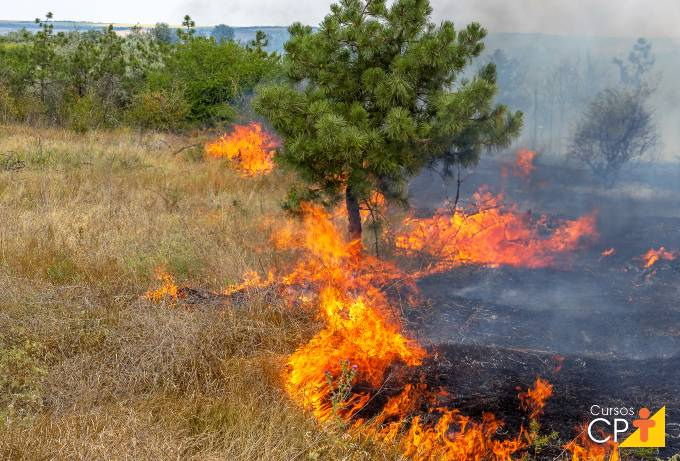

# **Base de Dados**
[Link do Download](https://drive.google.com/file/d/16PCjsLZuxmvxa0LlnTzCELbLVQhO37vN/view?usp=sharing)

In [173]:
# Libs necessárias

# Libs para Modelagem e Matrizes
import pandas as pd
import numpy as np

# Libs para análises gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Lib para ignorar avisos
import warnings

# Desabilitando avisos
warnings.filterwarnings('ignore')

In [174]:
# Lendo os dados
Base_Dados = pd.read_csv('Dados_Incendio.csv', encoding='latin-1' )

# Verificando
Base_Dados.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [175]:
# Nulos
Base_Dados.isnull().sum()

,0
year,0
state,0
month,0
number,0
date,0


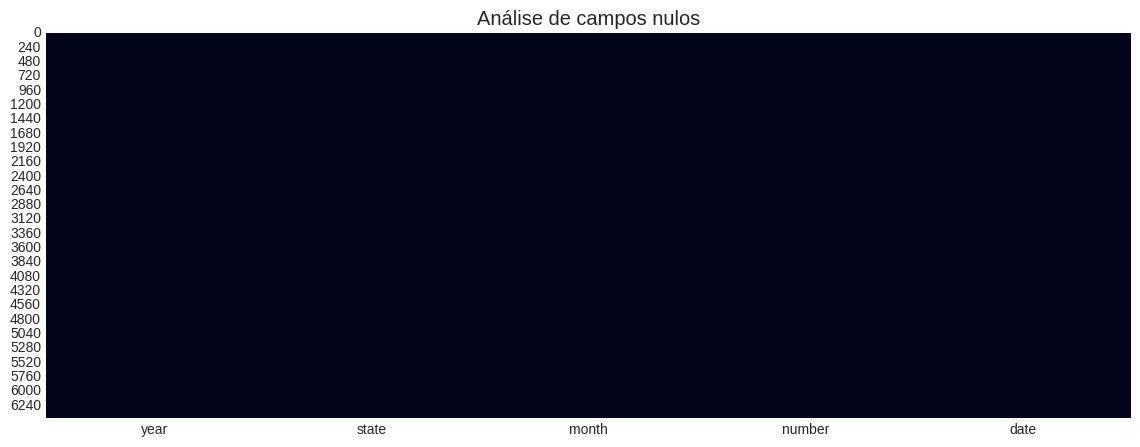

In [176]:
# Nulos Plot
plt.figure( figsize=(14, 5) )
plt.title('Análise de campos nulos')
sns.heatmap( Base_Dados.isnull(), cbar=False);

In [177]:
# Estatisticas
Base_Dados.describe()

,year,number
count,6454.000000,6454.000000
mean,2007.461729,108.293163
std,5.746654,190.812242
min,1998.000000,0.000000
25%,2002.000000,3.000000
50%,2007.000000,24.000000
75%,2012.000000,113.000000
max,2017.000000,998.000000


In [178]:
# Info
Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    6454 non-null   int64  
 1   state   6454 non-null   object 
 2   month   6454 non-null   object 
 3   number  6454 non-null   float64
 4   date    6454 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 252.2+ KB


In [179]:
# Campos unicos
Base_Dados.nunique()

,0
year,20
state,23
month,12
number,1479
date,20


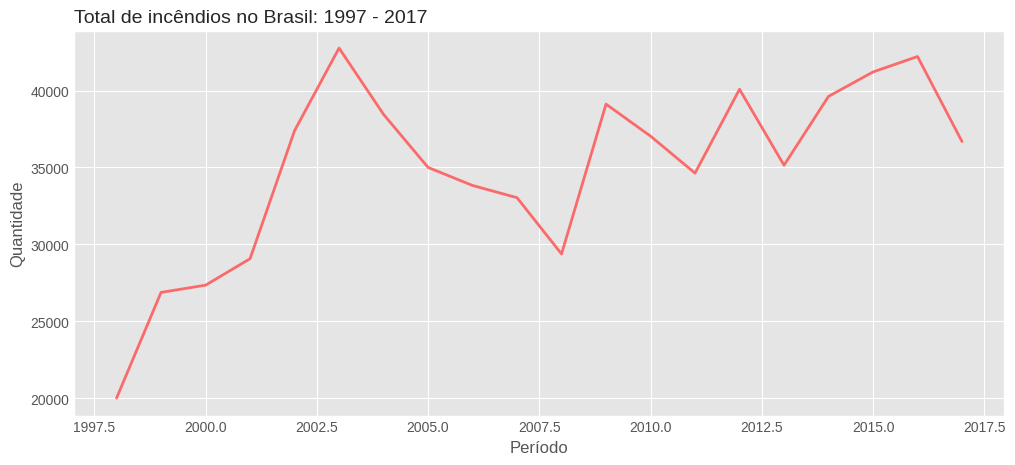

In [180]:
# Analise por ano dos incendios
Analise = Base_Dados.groupby( by=['year'] ).sum(numeric_only=True).reset_index()

Analise.head()

# Tamanho
plt.figure( figsize=(12, 5) )

# Style
plt.style.use('ggplot')

# Titulo
plt.title('Total de incêndios no Brasil: 1997 - 2017', loc='left', fontsize=14 )

# Grafico
sns.lineplot( data=Analise, x='year', y='number', estimator='sum', lw=2, color='#ff5555', alpha=0.85)

# Labels
plt.xlabel('Período')
plt.ylabel('Quantidade');

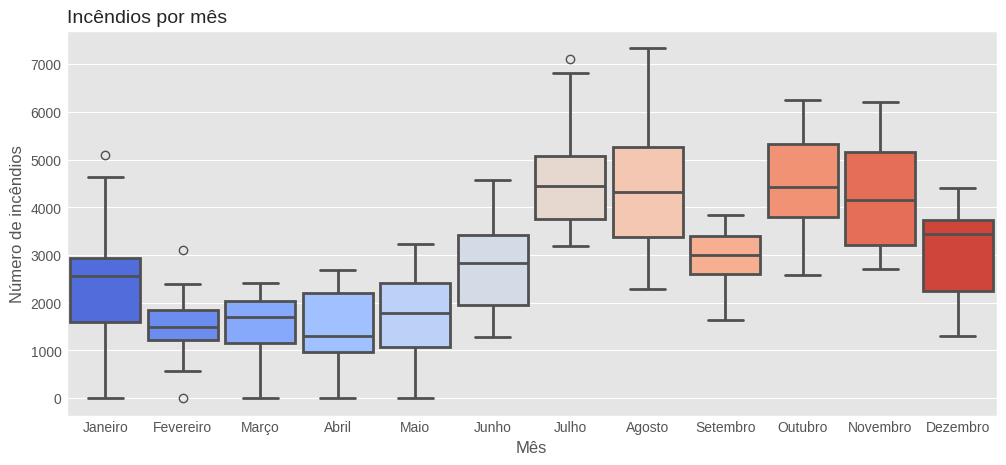

In [181]:
# Analise por ano dos incendios
Analise_02 = Base_Dados.groupby( by= ['year', 'month'] ) .sum(numeric_only=True).reset_index()

Analise_02.head()

# Tamanho
plt.figure( figsize=(12, 5) )

# Titulo
plt.title('Incêndios por mês', loc='left', fontsize=14 )

# Grafico
sns.boxplot( data=Analise_02, x='month', y='number', palette='coolwarm', saturation=1, width=0.9, linewidth=2,
            order=['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'] )

# Labels
plt.xlabel('Mês')
plt.ylabel('Número de incêndios');

In [182]:
# Analise por estados dos incendios
Analise_03 = Base_Dados.groupby( by= ['state'] ) .sum(numeric_only=True).reset_index()[['state', 'number']].sort_values( 'number', ascending=False)
Analise_03.head()

,state,number
10,Mato Grosso,96246.028
12,Paraiba,52435.918
20,Sao Paulo,51121.198
16,Rio,45160.865
4,Bahia,44746.226


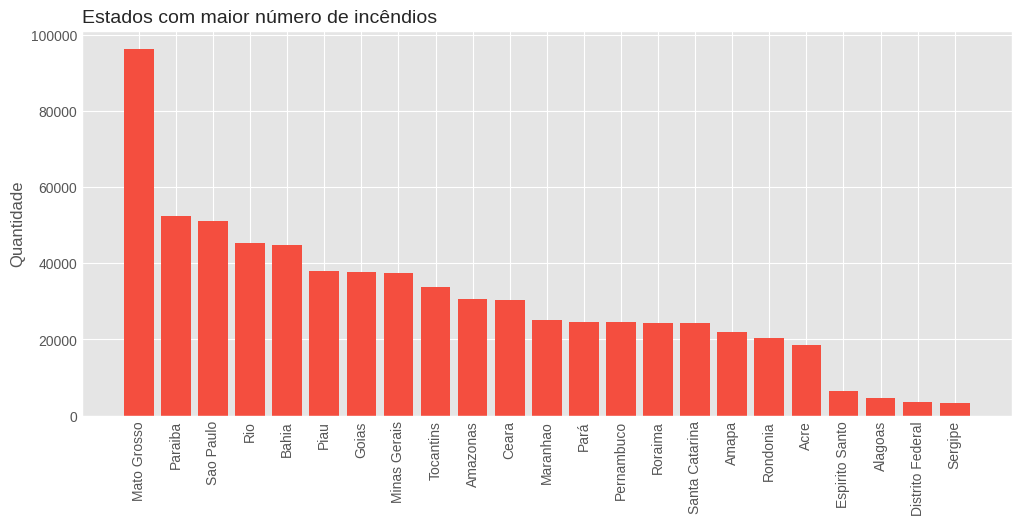

In [183]:
Analise_03

# Tamanho
plt.figure( figsize=(12, 5) )

# Titulo
plt.title('Estados com maior número de incêndios', loc='left', fontsize=14 )

# Grafico
plt.bar( Analise_03.state, Analise_03['number'], color='#f44e3f' )

# Labels
plt.ylabel('Quantidade')
plt.xticks( rotation=90 );

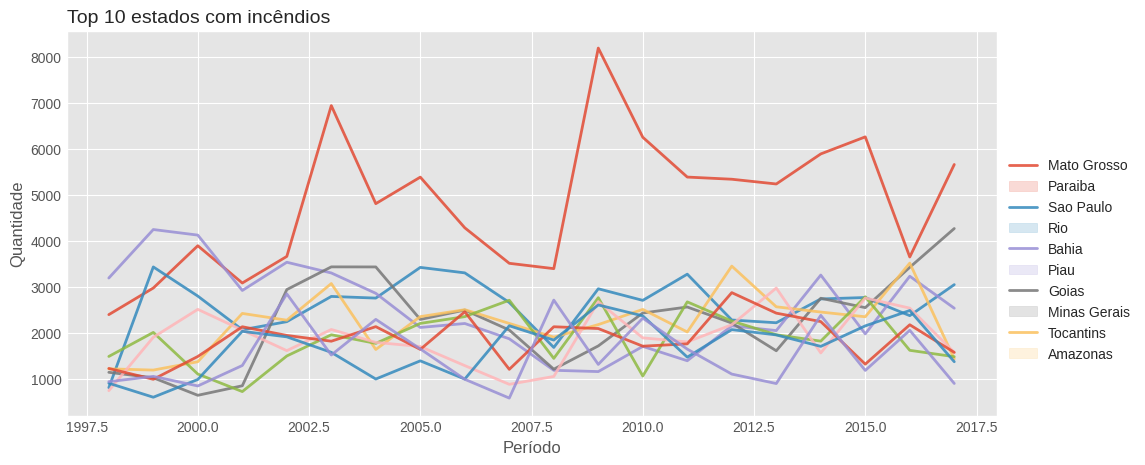

In [184]:
Lista_TOP10 = Analise_03['state'][0:10].values

# Tamanho
plt.figure( figsize=(12, 5) )

# Titulo
plt.title('Top 10 estados com incêndios', loc='left', fontsize=14 )

for Coluna in Lista_TOP10:
    # Filtrar o estado
    Filtro = Base_Dados.loc[ Base_Dados['state'] == Coluna]

    # Agrupar os valores para sumarizar
    Analise_Local = Filtro.groupby( by=['year'] ).sum(numeric_only=True).reset_index()

    # PLot
    sns.lineplot(data=Analise_Local, x='year', y='number', lw=2, alpha=0.85 )

# Labels
plt.xlabel('Período')
plt.ylabel('Quantidade')

# Legenda
plt.legend( Lista_TOP10, bbox_to_anchor=(1, 0.7) );

In [185]:
# Plot Geográfico

# Gerando os estados
Estados = Analise_03.sort_values('state')['state'].values

# Gerando os valores
Valores = Analise_03.sort_values('state')['number'].values

# Latitudes
Lat = [ -8.77, -9.71,	1.41, -3.07,	-12.96, -3.71, -15.83, -19.19, -16.64, -2.55,	-12.64,
       -18.10, -7.06, -5.53, -8.28, -8.28,	-22.84,	-11.22,	1.89,	-27.33,	-23.55,	-10.90,	-10.25 ]

# Longitudes
Log = [ -70.55,	-35.73,	-51.77,	-61.66,	-38.51,	-38.54,	-47.86,	-40.34,	-49.31,	-44.30,	-55.42,	-44.38,
       -35.55,	-52.29,	-35.07,	-43.68,	-43.15,	-62.80,	-61.22,	-49.44,	-46.64,	-37.07,	-48.25 ]

# Organizando os dados
Dicionario= {
    'Estados' : Estados,
    'Latitude' : Lat,
    'Longitude' : Log,
    'Incêndios' : Valores
    }

# Lendo o dicionário
Analise_Geografica = pd.DataFrame ( Dicionario )

Analise_Geografica.head()

,Estados,Latitude,Longitude,Incêndios
0,Acre,-8.77,-70.55,18464.030
1,Alagoas,-9.71,-35.73,4644.000
2,Amapa,1.41,-51.77,21831.576
3,Amazonas,-3.07,-61.66,30650.129
4,Bahia,-12.96,-38.51,44746.226


In [188]:
# Fazendo o plot
import plotly.express as px

# Mapa de Calor Geografico
px.density_mapbox(
   Analise_Geografica,
   lat='Latitude',
   lon='Longitude',
   z='Incêndios',
   radius=30,
   center=dict(lat=-12.700, lon=-46.5555),
   zoom=3,
   mapbox_style='open-street-map'
)